# 04_02 Slope

## 1. Introduction

This notebook derives and visualizes terrain slope from the existing elevation dataset.

**Data Source: S2**

The slope raster used in this notebook was provided directly within the S2 dataset as a precomputed terrain product. Because the slope layer was already available, it was not necessary to derive slope manually from the DEM.

Slope represents the rate of change in elevation across the landscape and is one of the primary controls on surface runoff and water movement.

This work builds directly on the clipped elevation model developed in the Elevation notebooks. Because the study boundary and projection were established previously, the same projected boundary is reused here to maintain spatial consistency.

See:

- **03_04_Dataset_Compatibility_Analysis**
- **03_05_Clipping_Data_To_Bounds**

for additional discussion of coordinate systems, reprojection, and clipping operations.

The purpose of this notebook is to examine terrain slope as an independent hydrological variable without repeating the elevation preprocessing workflow.

### Slope Definition

- **Slope** → rate of elevation change across the terrain surface.
    - Higher slope generally corresponds to faster potential surface runoff.
    - Lower slope indicates flatter terrain and reduced gravitational flow.

Slope is one of the most important terrain derivatives because it influences:

- surface runoff
- erosion potential
- drainage patterns
- watershed development
- flood behavior

This layer will later be used for:

- flow strength estimation
- flow direction analysis
- watershed interpretation
- hydrological modelling

### Mathematical Definition

If the elevation surface is represented as:

$$
z = f(x,y)
$$

where:

- $z$ = elevation
- $x$ = horizontal position
- $y$ = horizontal position

then the local slope depends upon how rapidly elevation changes in each horizontal direction:

$$
\frac{\partial z}{\partial x}
$$

and

$$
\frac{\partial z}{\partial y}
$$

The overall slope magnitude is computed using the gradient:

$$
|\nabla z|
=
\sqrt{
\left(
\frac{\partial z}{\partial x}
\right)^2
+
\left(
\frac{\partial z}{\partial y}
\right)^2
}
$$

This equation combines elevation changes in both horizontal directions to determine the total steepness at each location.

In practice:

- Flat terrain produces values near zero.
- Steeper terrain produces larger values.
- The direction of maximum change points downhill.

Most GIS software performs these calculations automatically using neighboring elevation cells.

### Percent Rise

Another common method for representing slope is **percent rise**:

$$
\text{Slope (\%)}
=
100
\left(
\frac{\text{vertical rise}}
{\text{horizontal run}}
\right)
$$

For example:

$$
100
\left(
\frac{1}{1}
\right)
=
100\%
$$

which corresponds to:

$$
\theta = \tan^{-1}(1)
= 45^\circ
$$

This relationship produces:

| Slope Angle | Percent Rise |
|------------|-------------|
| 0° | 0% |
| 10° | 17.6% |
| 20° | 36.4% |
| 30° | 57.7% |
| 45° | 100% |

As the slope approaches vertical, percent rise approaches infinity because the horizontal distance approaches zero.

### Behaviour Near Vertical Slopes (Discontinuities and Numerical Limits)

As slope approaches a vertical surface, the percent rise formulation highlights a fundamental mathematical limitation. Since slope is defined as:

$$
\text{Slope (\%)} = 100 \cdot \frac{\text{rise}}{\text{run}}
$$

a vertical surface corresponds to:

$$
\text{run} \rightarrow 0
\quad \Rightarrow \quad
\frac{\text{rise}}{\text{run}} \rightarrow \infty
$$

This creates a **singularity** in the continuous formulation of slope, where the value becomes unbounded. In theory, a perfectly vertical surface corresponds to an undefined or infinite slope.

However, this situation does not appear directly in raster-based terrain analysis. Digital elevation models represent the landscape as a discrete grid:

- Each cell contains a single elevation value
- Slopes are computed between neighbouring cells
- The surface is therefore **piecewise discrete rather than continuous**

Because of this structure, true mathematical discontinuities (such as vertical cliffs) cannot be represented explicitly. Instead, they appear as:

- very large but finite slope values, or  
- abrupt transitions across adjacent grid cells

In this sense, vertical features are treated as **numerical approximations of discontinuities**, rather than explicit geometric objects.

A useful reference frame for interpretation is:

- **100% slope** = 45° (moderate to steep terrain transition)  
- **200–300% slope** = extremely steep hillside / near cliff-like conditions  
- **1000%+ slope** = effectively vertical for most environmental modelling purposes  

Despite the theoretical divergence, this does not pose a practical issue for hydrological modelling. Since the dataset is discretized, all derivatives are approximated over finite distances, ensuring slope remains bounded and computationally stable. In practice, very high slopes are often interpreted as flow barriers or rapidly draining terrain rather than true geometric infinities.

## 2. Data Unit Analysis

In [10]:
with rasterio.open("../../data/Elevation/CDEM/DEM.tif") as src:
    print("DEM CRS:", src.crs)
    print("DEM Resolution:", src.res)

with rasterio.open("../../data/Elevation/CDEM/SLOPE.tif") as src:
    print("Slope CRS:", src.crs)
    print("Slope Resolution:", src.res)

    slope_data = src.read(1)

    if src.nodata is not None:
        slope_data = np.where(
            slope_data == src.nodata,
            np.nan,
            slope_data
        )

print()
print("Minimum Slope:", np.nanmin(slope_data))
print("Maximum Slope:", np.nanmax(slope_data))
print("Mean Slope:", np.nanmean(slope_data))

DEM CRS: EPSG:4617
DEM Resolution: (0.000381725417439701, 0.00038172003662425956)
Slope CRS: EPSG:4617
Slope Resolution: (0.000381725417439701, 0.0003817200366242595)

Minimum Slope: 0.0
Maximum Slope: 115.815704
Mean Slope: 2.3860424


### Unit Analysis Result

Inspection of the DEM and slope rasters shows that both datasets share the same coordinate reference system:

$$
\text{EPSG:4617}
$$

This coordinate system stores horizontal positions using latitude and longitude coordinates.

The slope raster contains values ranging approximately from:

- Minimum: 0
- Maximum: 116
- Mean: 2.4

***Note that this computation was done before I clipped the slope data so it extends beyond the region boundary.***

Since slope angles cannot exceed:

$$
90^\circ
$$

the observed maximum value demonstrates that the raster cannot represent slope angle measured in degrees.

Instead, the observed range strongly suggests that the slope raster is reported as **percent rise**.

A slope value of:

$$
100
$$

corresponds to a:

$$
45^\circ
$$

terrain slope.

Similarly:

$$
116\%
$$

corresponds to approximately:

$$
49^\circ
$$

using:

$$
\theta = \tan^{-1}
\left(
\frac{\text{percent rise}}{100}
\right)
$$

Although Waterloo Region is characterized by relatively gentle topography, localized river valleys, embankments, and steep terrain features can still produce slope values approaching 50 degrees.

Based on the observed data range, the slope raster will therefore be interpreted as percent rise throughout the remainder of this notebook.

## 3. Imports

In [11]:
import geopandas as gpd
import rasterio
import rasterio.mask
import numpy as np
import matplotlib.pyplot as plt

## 4. Load Boundary (Projected Study Area)

In [12]:
boundary = gpd.read_file("../../data/Boundaries/boundary_projected.geojson")

## 5. Load Slope Raster and Clip to Boundary

In [13]:
slope_path = "../../data/Elevation/CDEM/SLOPE.tif"

with rasterio.open(slope_path) as src:
    out_image, out_transform = rasterio.mask.mask(
        src,
        boundary.geometry,
        crop=True
    )
    out_meta = src.meta

# Convert to 2D array (single band assumption)
slope_clipped = out_image[0]
nodata = out_meta.get("nodata")

if nodata is not None:
    slope_clipped = np.where(slope_clipped == nodata, np.nan, slope_clipped)

## 6. Visualization

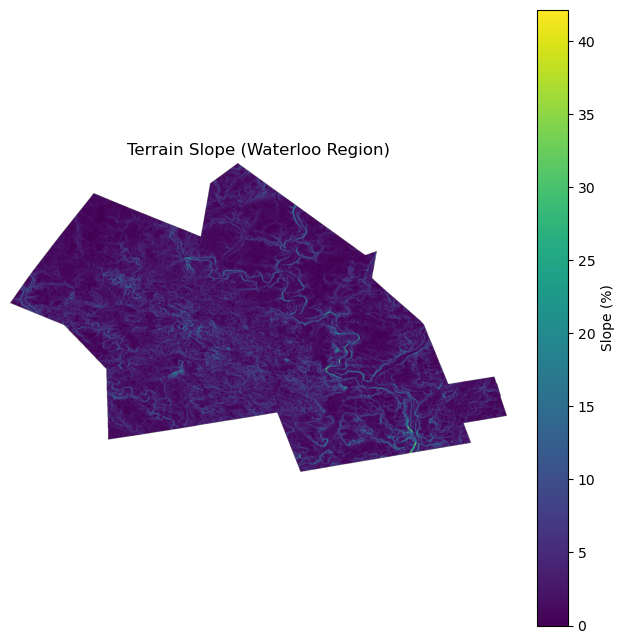

In [14]:
plt.figure(figsize=(8, 8))

plt.imshow(
    slope_clipped,
    cmap="viridis"
)

plt.title("Terrain Slope (Waterloo Region)")
plt.axis("off")

plt.colorbar(
    label="Slope (%)"
)

plt.show()

## 6. Slope Metadata

Above we showed maximum and minimum slope, however now that we have clipped to the region boundary, those numbers will have changed so we can perform that analysis again.

In [18]:
print(f"Minimum Slope: {np.nanmin(slope_clipped):.2f}%")
print(f"Maximum Slope: {np.nanmax(slope_clipped):.2f}%")
print(f"Mean Slope: {np.nanmean(slope_clipped):.2f}%")

Minimum Slope: 0.00%
Maximum Slope: 42.16%
Mean Slope: 2.90%


## 7. (Optional) Save Clipped Slope

Only save if this clipped version will be reused in later notebooks.
If notebooks are purely exploratory, this can be skipped.

In [15]:

save_slope = False

if save_slope:
    out_meta.update({
        "height": slope_clipped.shape[0],
        "width": slope_clipped.shape[1],
        "transform": out_transform
    })

    clipped_slope_path = "../../data/clipped_slope.tif"

    with rasterio.open(clipped_slope_path, "w", **out_meta) as dest:
        dest.write(slope_clipped, 1)